<a href="https://colab.research.google.com/github/mediolanum1/dla/blob/2024/Copy_of_DFT_Spectogramms_IR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torchaudio
!pip install soundfile
!pip install torchaudio-filters

In [2]:
import numpy as np
import torch
import torchaudio
import torchaudio_filters as tf

import soundfile as sf
import matplotlib.pyplot as plt
%matplotlib inline
from IPython import display


In [3]:
wav, sr = sf.read('example.wav')

In [4]:
print(f"Sample rate: {sr}Hz")
print(f"Wav( {len(wav)} samples): ", wav) # np nd-array

Sample rate: 44100Hz
Wav( 341932 samples):  [[ 0.00000000e+00  0.00000000e+00]
 [ 3.05175781e-05  0.00000000e+00]
 [-9.15527344e-05  3.05175781e-05]
 ...
 [-1.37115479e-01  1.28173828e-01]
 [-1.37451172e-01  1.27960205e-01]
 [-1.37847900e-01  1.28021240e-01]]


In [5]:
wav, sr = torchaudio.load("example.wav")

In [6]:
print(f"Sample rate: {sr}Hz")
print(f"Wav( {len(wav)} samples): ", wav) # np nd-array

Sample rate: 44100Hz
Wav( 2 samples):  tensor([[ 0.0000e+00,  3.0518e-05, -9.1553e-05,  ..., -1.3712e-01,
         -1.3745e-01, -1.3785e-01],
        [ 0.0000e+00,  0.0000e+00,  3.0518e-05,  ...,  1.2817e-01,
          1.2796e-01,  1.2802e-01]])


In [7]:
wav.shape # 2 as its stereo=

torch.Size([2, 341932])

In [8]:
def visualize_audio(wav: torch.Tensor, sr: int = 22050, monoConvert: bool = False):
  """
  Args:
    sr - sample rate - 22050 by def
    wav - waveform (Nch, T) or (T,)
  """
  if (monoConvert):
    # averagin all channels
    if (len(wav.shape) > 1):
      # Any to mono conversion
      wav = wav.mean(dim = 0)

    _, ax = plt.sublpots(figsize=(14,4))
    ax.plot(np.arange(0, wav.shape[0]/sr, 1/sr), wav, alpha = 0.7, c = "green")
    ax.grid()
    ax.set_xlabel('Time, sec', size = 20)
    ax.set_ylabel('Amplitude', size = 20)
    display(plt.show())
  else:
    nChannels = wav.shape[0]
    if (nChannels == 1):
      _, ax = plt.subplots(figsize = (14,4))
      ax.plot(np.arange(0, wav.shape[1]/sr, 1/sr), wav[0,:], alpha = 0.7, c = "green")
      ax.grid()
      ax.set_xlabel('Time, sec', size = 20)
      ax.set_ylabel('Amplitude', size = 20)

    else:
      _, axs = plt.subplots(nChannels, 1, figsize = (14,4*nChannels))
      for id,ax in enumerate(axs):
        ax.plot(np.arange(0, wav.shape[1]/sr, 1/sr), wav[id,:], alpha = 0.7, c = "green")
        ax.grid()
        ax.set_xlabel('Time, sec', size = 20)
        ax.set_ylabel(f'Amplitude, Ch={id+1}', size = 20)
  plt.show()

  display.display(display.Audio(wav, rate = sr))

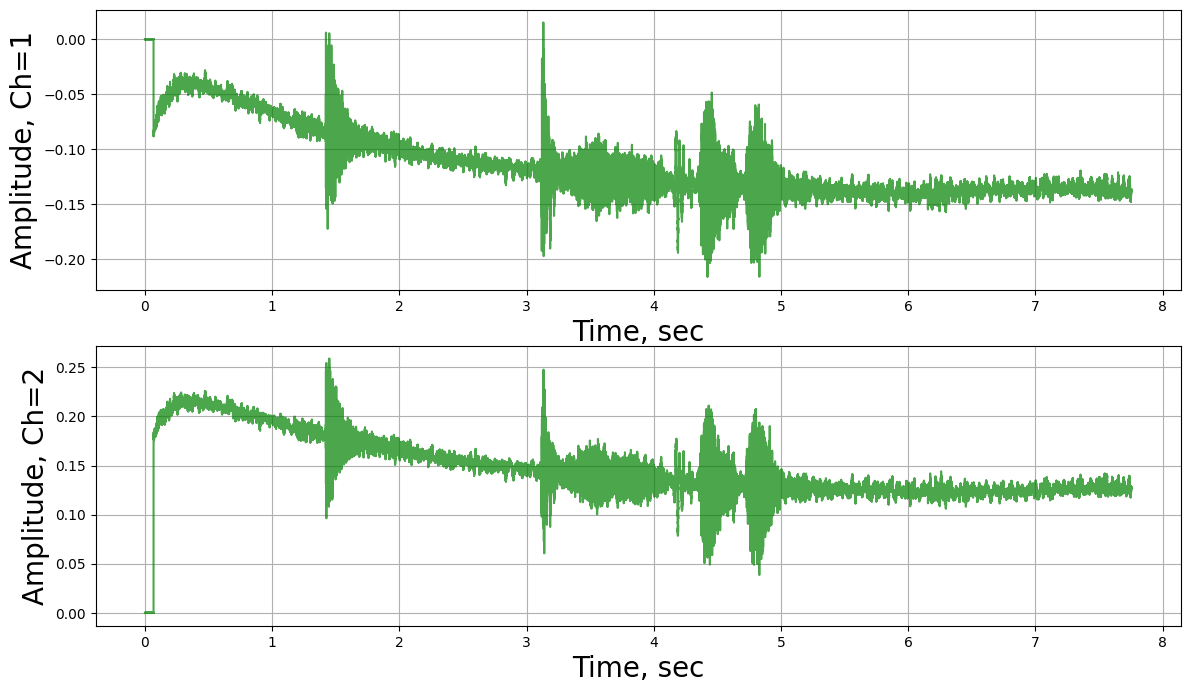

In [9]:
visualize_audio(wav, sr)


In [10]:
wav = wav.mean(dim = 0, keepdim=True)

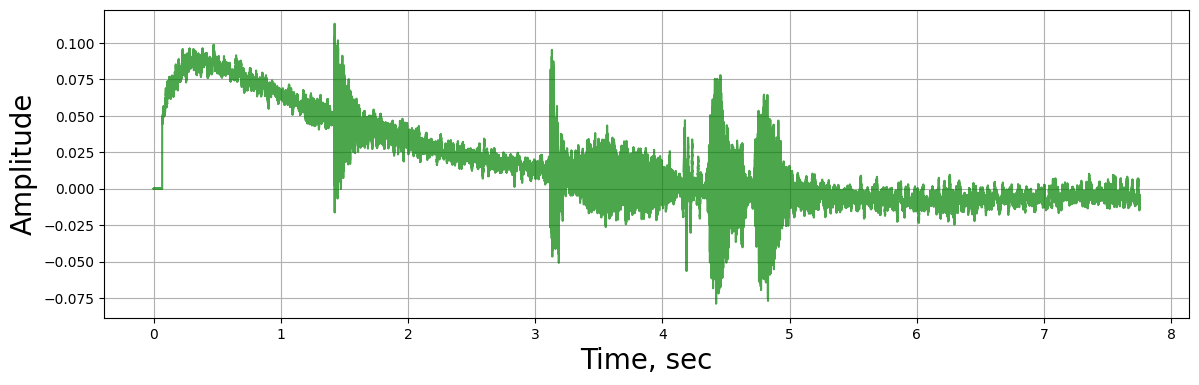

In [11]:
visualize_audio(wav, sr)

### **Discrete Fourier Transform and stuff**

In [12]:
nFFT = 1024 # ok its not first n samples, its number of points used in FFT that will affect frequency resolution that is sr/nFFT
spectrum = torch.fft.fft(wav, n = nFFT) # compute DFT with fft
spectrumR = torch.fft.rfft(wav, n = nFFT) # returns spectrum below Nyqist freq, so size will be nFFT/2

In [13]:
print(f"spectrum.dtype={spectrum.dtype}, spectrum.shape={spectrum.shape}")
print(f"spectrumR.dtype={spectrumR.dtype}, spectrumR.shape={spectrumR.shape}")

spectrum.dtype=torch.complex64, spectrum.shape=torch.Size([1, 1024])
spectrumR.dtype=torch.complex64, spectrumR.shape=torch.Size([1, 513])


In [14]:
freq = np.arange(0, nFFT)/nFFT*sr # computing the frequencies
freqR = np.arange(0, nFFT//2 + 0.0001)/nFFT*sr # 0.0001 is like a костыль короч чтоб все уместить
freqR.shape

(513,)

In [15]:
power_spectrum = spectrum.abs()**2
power_spectrumR = spectrumR.abs()**2
print(power_spectrum.shape)
print(power_spectrumR.shape)

torch.Size([1, 1024])
torch.Size([1, 513])


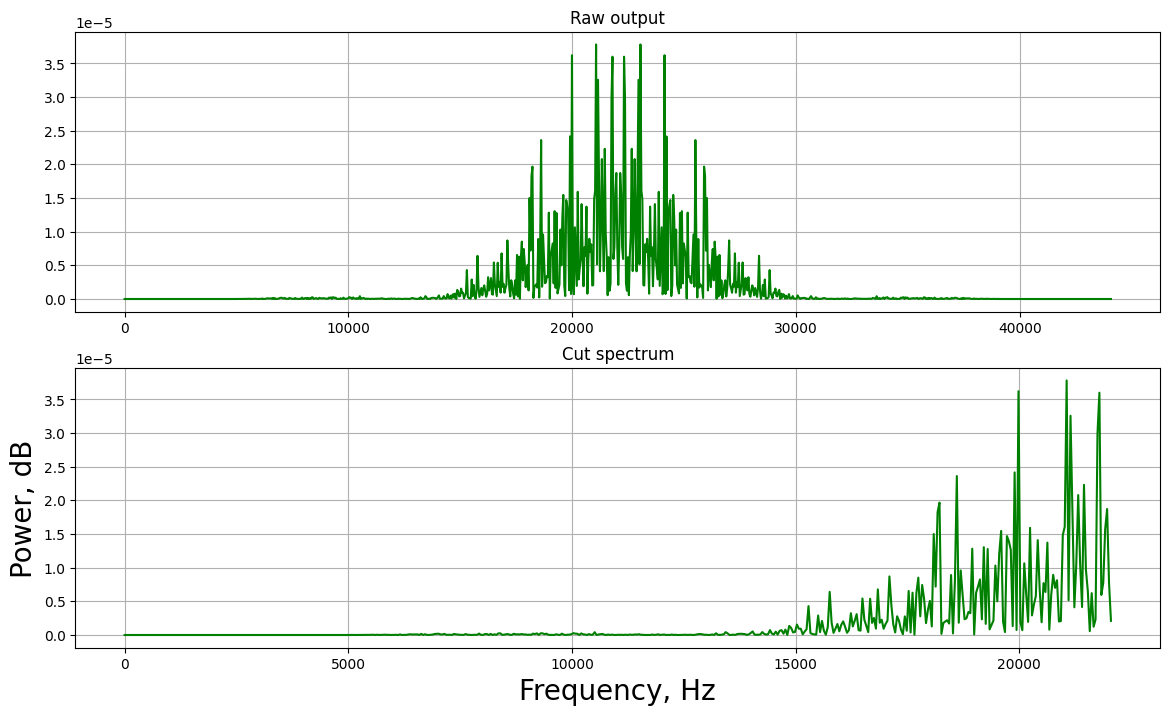

In [16]:
f,(ax1, ax2) = plt.subplots(2,1, figsize = (14,8))

ax1.grid()
ax1.set_title("Raw output")
ax1.plot(freq, power_spectrum.squeeze(), c='green')

ax2.grid()
ax2.set_title("Cut spectrum")
ax2.plot(freqR, power_spectrumR.squeeze(), c='green')
ax2.set_xlabel("Frequency, Hz", size = 20)
ax2.set_ylabel("Power, dB", size = 20)
plt.show()

For better visual quality we take mel-specs so decibel scale is relative


In [17]:
def mel_forward(f):
  return 2595 * np.log10(1 + f/700) # just a formual from wiki, we can use others too
def mel_inverse(m):
  return 700 * (10**(m/2595) - 1)
p0 = 1#dBFS- dB relative to full scale, idk
def dB_forward(p):
  return 10 * np.log10(p/p0)
def dB_inverse(p):
  return 10 ** (p/10) * p0


<ipython-input-17-fd3da920043c>:2: RuntimeWarning: invalid value encountered in log10
  return 2595 * np.log10(1 + f/700) # just a formual from wiki, we can use others too


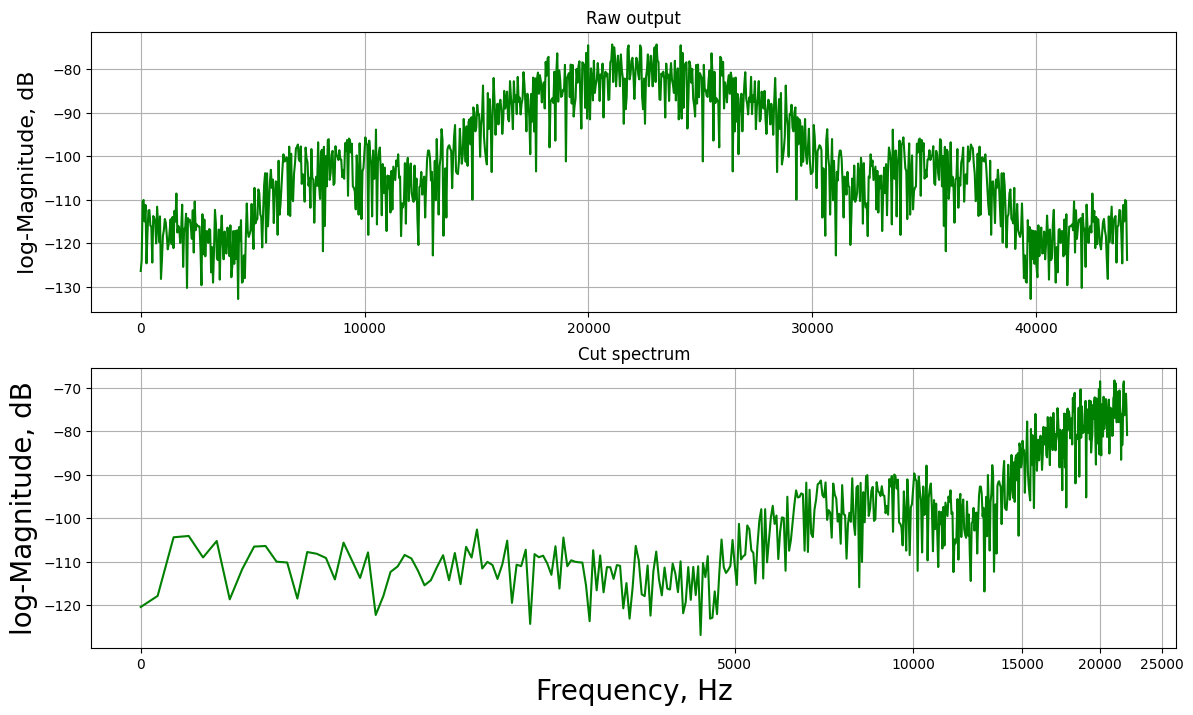

In [18]:
f, (ax1, ax2) = plt.subplots(2,1, figsize = (14,8))

ax1.grid()
ax1.set_title("Raw output")
ax1.plot(freq, dB_forward(power_spectrum.squeeze()/power_spectrum.shape[-1]), c='green')
ax1.set_ylabel("log-Magnitude, dB", size=16)

ax2.grid()
ax2.set_title("Cut spectrum")
ax2.plot(freqR, dB_forward(2*power_spectrumR.squeeze()/power_spectrumR.shape[-1]), c='green')
ax2.set_xlabel("Frequency, Hz", size = 20)
ax2.set_ylabel("log-Magnitude, dB", size = 20)
ax2.set_xscale("function", functions = (mel_forward, mel_inverse))

plt.show()

If we do STFT, short signal frames are commonly used like (512, 1024, 2048) for FFT, and there is a problem of leakage effects and alliasing. Это происходит так как FFT мы делаем по очень маленьким окнам типа 1024 и в частоте 44к это очень малеьнкий отрезок времени, поэтому супер высокие частоты отследить мы не можем.  Возьмем пример синусоиду которую мы будем считывать с sample rate 2к --> meaning we take contin signal and read signal 2k times in sec to make discrete.

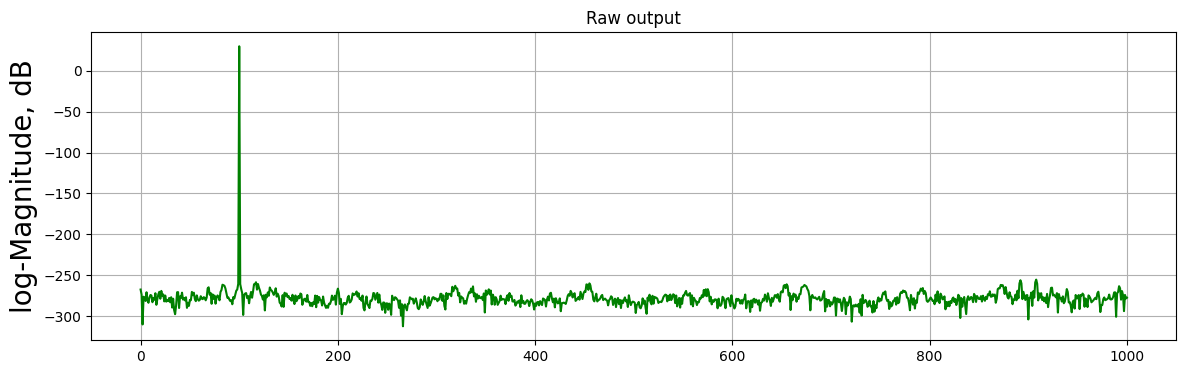

In [19]:
xs = np.sin(2*np.pi*100*np.arange(0,1,1/2000)) # здесь мы создаем синусоиду которую семплируем с частотой в 2к с
                                                # с  частотой в 100
xsSpectrum = np.abs(np.fft.rfft(xs))**2 # здесь берерм фурье этой синусоиды и берем ток действительные положительные числа
xsFreqs = np.arange(0, len(xs)//2 + 0.001) / len(xs)*2000  # здесь мы создаем x-axis для этого мы берем длинну сигнала
# и идем с шагом 1/n, то есть отсчеты будут 0, 1/n, 2/n.... and this way till 1, но эти отсчеты в шагах измерены, to get
# freqs, we multiply them by sample rate and this way we get freqs

f1, ax1 = plt.subplots(figsize = (14,4))

ax1.grid()
ax1.set_title("Raw output")
ax1.plot(xsFreqs, dB_forward(xsSpectrum.squeeze()/xsSpectrum.shape[-1]), c = "green")
ax1.set_ylabel("log-Magnitude, dB", size = 20)
plt.show()



 но что будет если частота синусоиды будет не 100, а 1000 --> то есть выше частоты Nyqist


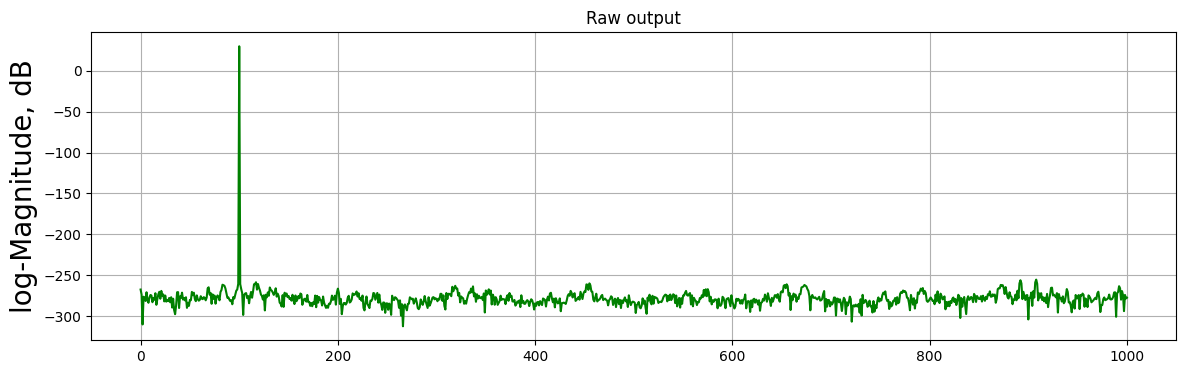

In [20]:
xs = np.sin(2*np.pi*100*np.arange(0,1,1/2000)) # здесь мы создаем синусоиду которую семплируем с частотой в 2к с
                                                # с  частотой в 100
xsSpectrum = np.abs(np.fft.rfft(xs))**2 # здесь берерм фурье этой синусоиды и берем ток действительные положительные числа
xsFreqs = np.arange(0, len(xs)//2 + 0.001) / len(xs)*2000  # здесь мы создаем x-axis для этого мы берем длинну сигнала
# и идем с шагом 1/n, то есть отсчеты будут 0, 1/n, 2/n.... and this way till 1, но эти отсчеты в шагах измерены, to get
# freqs, we multiply them by sample rate and this way we get freqs

f1, ax1 = plt.subplots(figsize = (14,4))

ax1.grid()
ax1.set_title("Raw output")
ax1.plot(xsFreqs, dB_forward(xsSpectrum.squeeze()/xsSpectrum.shape[-1]), c = "green")
ax1.set_ylabel("log-Magnitude, dB", size = 20)
plt.show()



появляется эффект алиазинга когда FFT видит частоты которых нет. Чтобы решить эти проблемы мы используем Hann Window который позволяет сглаживать устрые углы которые создаются когда мы sampling сигнал и попадаем в окно когда сигнал не переодический и поэтому резкие углы создают впечатления высоких частот.

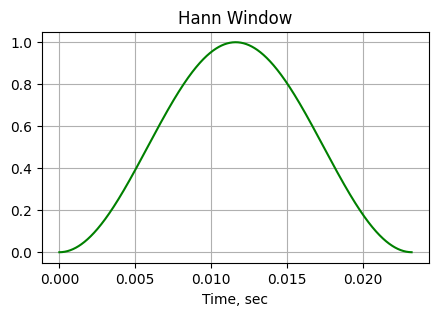

In [21]:
windowSize = nFFT
window = torch.hann_window(windowSize)

f,ax = plt.subplots(figsize=(5,3))
ax.grid()
ax.set_title("Hann Window")
ax.plot(np.arange(0,nFFT)/sr, window, c = "green")
ax.set_xlabel("Time, sec")
plt.show()

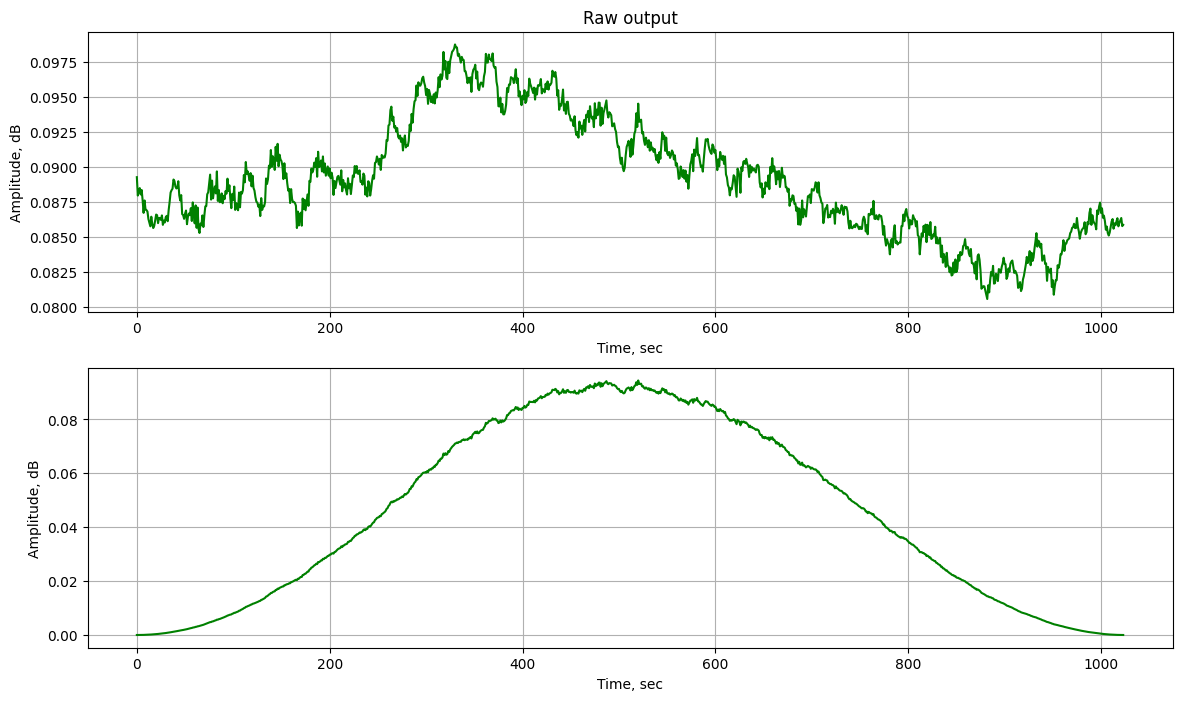

In [22]:
wavClipped = wav[:, 20*windowSize:21*windowSize] # extracting 20-21 window
wavClippedWindowed = window * wavClipped # applies Hann Window to segment

fig, (ax1, ax2) = plt.subplots(2,1, figsize = (14,8))
ax1.grid()
ax1.plot(wavClipped.squeeze(), c = "green")
ax1.set_title("Raw output")
ax1.set_xlabel("Time, sec")
ax1.set_ylabel("Amplitude, dB")

ax2.grid()
ax2.plot(wavClippedWindowed.squeeze(), c = "green")
ax2.set_xlabel("Time, sec")
ax2.set_ylabel("Amplitude, dB")
plt.show()

Теперь на реальном примере

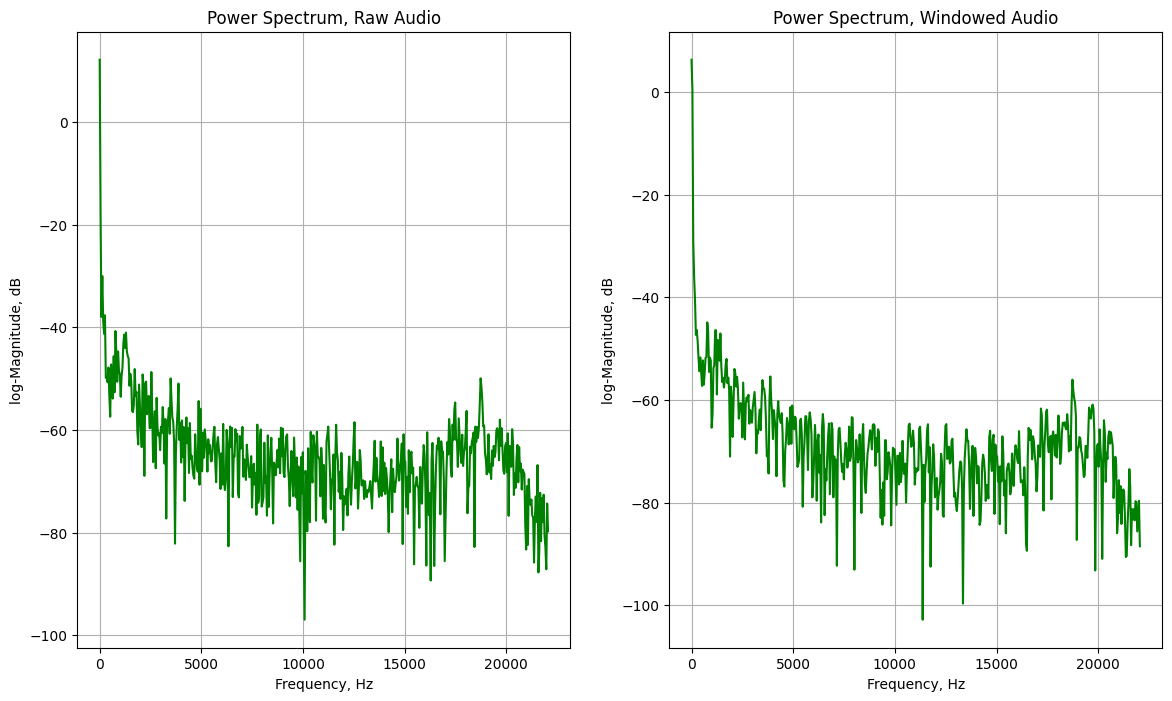

In [23]:
spectrum = torch.fft.rfft(wavClipped).abs().pow(2)
spectrumWindowed = torch.fft.rfft(wavClippedWindowed).abs().pow(2)

fig, (ax1,ax2) = plt.subplots(1,2, figsize = (14,8))

ax1.grid()
ax1.set_title("Power Spectrum, Raw Audio")
ax1.plot(freqR, dB_forward(spectrum.squeeze()/spectrum.shape[-1]), c = "green")
ax1.set_xlabel("Frequency, Hz")
ax1.set_ylabel("log-Magnitude, dB")

ax2.grid()
ax2.set_title("Power Spectrum, Windowed Audio")
ax2.set_xlabel("Frequency, Hz")
ax2.set_ylabel("log-Magnitude, dB")
ax2.plot(freqR, dB_forward(spectrumWindowed.squeeze()/spectrumWindowed.shape[-1]), c = "green")

plt.show()

In [24]:
nFFT = 1024
windowSize = nFFT
hop_size = 256
window = torch.hann_window(windowSize)

In [25]:
stft = torch.stft(
    wav,
    n_fft = nFFT,
    hop_length = hop_size,
    win_length= windowSize,
    window = window,
    center = False, # we dont want to center the input signal for padding
    onesided = True, # take freqs before Nyqist freq
    return_complex = True
    )


In [26]:
stft.shape

torch.Size([1, 513, 1332])

In [27]:
print(sr)
freqsR = np.arange(0, nFFT/2 + 0.0001)/nFFT*sr
print(freqsR.shape)
logSpectogram = 20 * torch.log10(torch.abs(stft)/window.sum())
logSpectogram.shape

44100
(513,)


torch.Size([1, 513, 1332])

Last dimension in Spectogramm is time. Each timestep is called frame

22050.0
(513, 1332) (513, 1332) torch.Size([1, 513, 1332])
tensor(-20.8046)


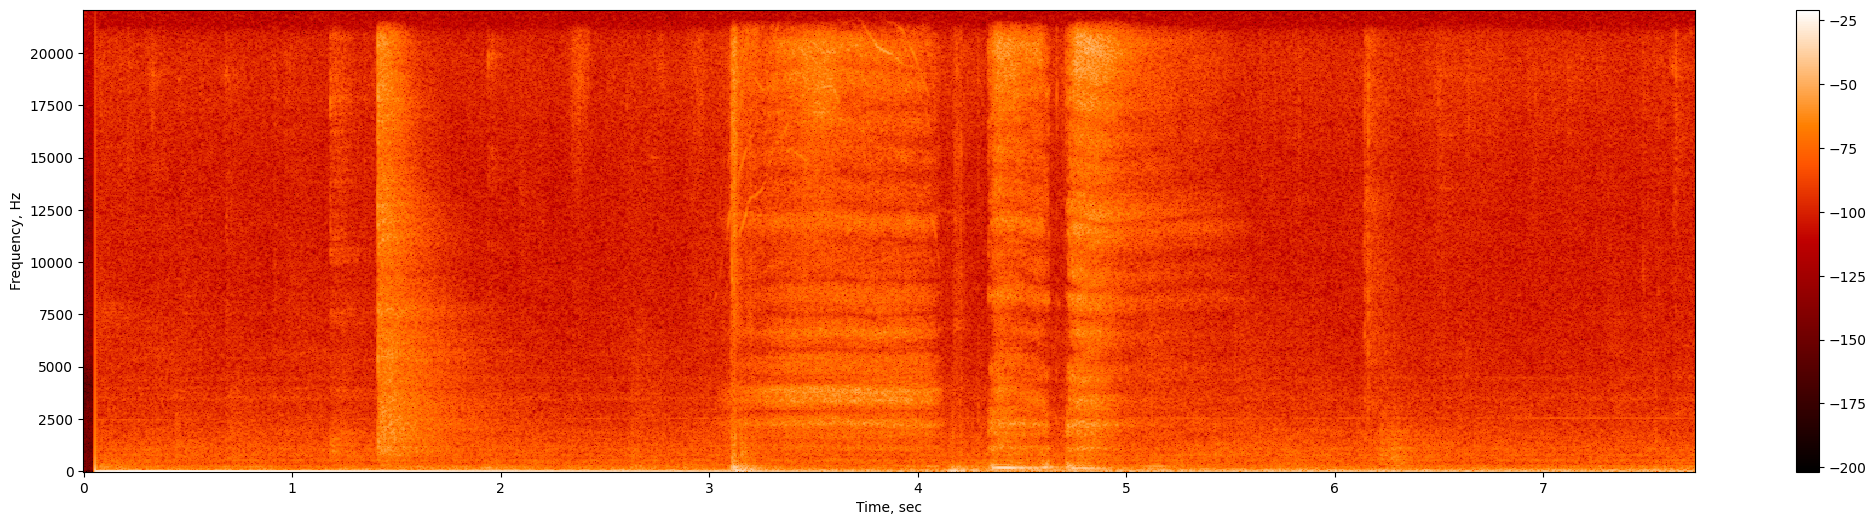

In [58]:
f,ax = plt.subplots(figsize = (26,6))

tGrid = np.arange(0, logSpectogram.shape[2]*hop_size, hop_size)/sr
fGrid = freqsR
print(freqsR[-1])
tt, ff = np.meshgrid(tGrid, fGrid)
print(tt.shape, ff.shape, logSpectogram.shape)
print(torch.max(logSpectogram))

im = ax.pcolormesh(tt, ff, logSpectogram.squeeze(), cmap = "gist_heat", antialiased=True)
ax.set_xlabel("Time, sec")
ax.set_ylabel("Frequency, Hz")
f.colorbar(im)
plt.show()

The last stage is Mel Spec. To init Mel Spec we will use torchaudio

In [29]:
nMels = 10
mel_scaler = torchaudio.transforms.MelScale(
    n_mels = nMels,
    sample_rate = sr,
    n_stft = nFFT // 2 + 1,
)


Mel Scaler is nothing more then rectangular matrix. that we will use for multiplication. We will multiply each frame in spectogramm by mel_scaler.fb matrix

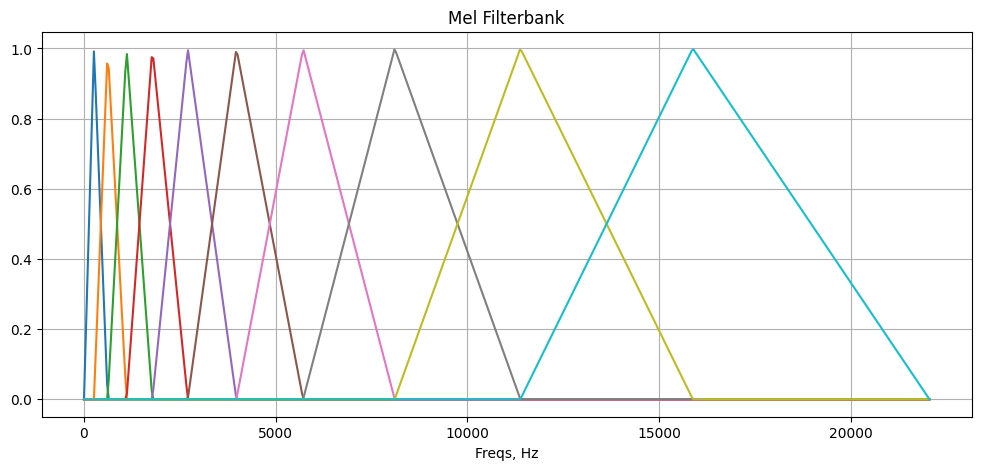

In [30]:
f, ax = plt.subplots(figsize=(12,5))

ax.grid()
ax.set_title("Mel Filterbank")
ax.set_xlabel("Freqs, Hz")
ax.plot(freqsR, mel_scaler.fb)
plt.show()

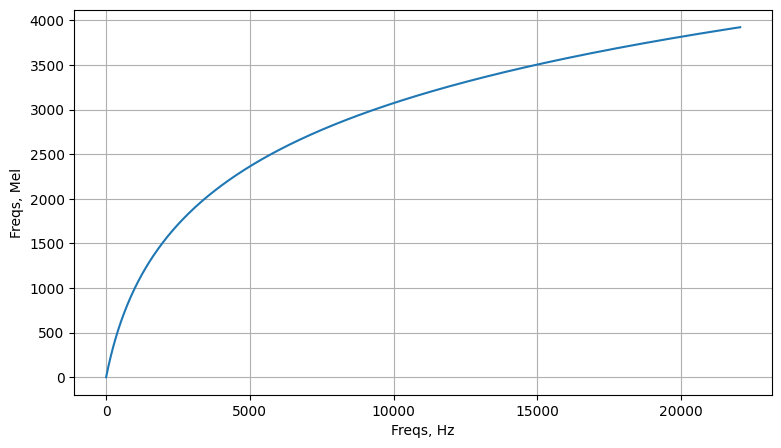

In [31]:
f ,ax = plt.subplots(figsize=(9,5))

ax.grid()
ax.set_xlabel("Freqs, Hz")
ax.set_ylabel("Freqs, Mel")
ax.plot(freqsR, mel_forward(freqsR))
plt.show()

In [32]:
melSpectogram = 20 * torch.log10(mel_scaler(torch.abs(stft)))

In [33]:
melSpectogram.shape

torch.Size([1, 10, 1332])

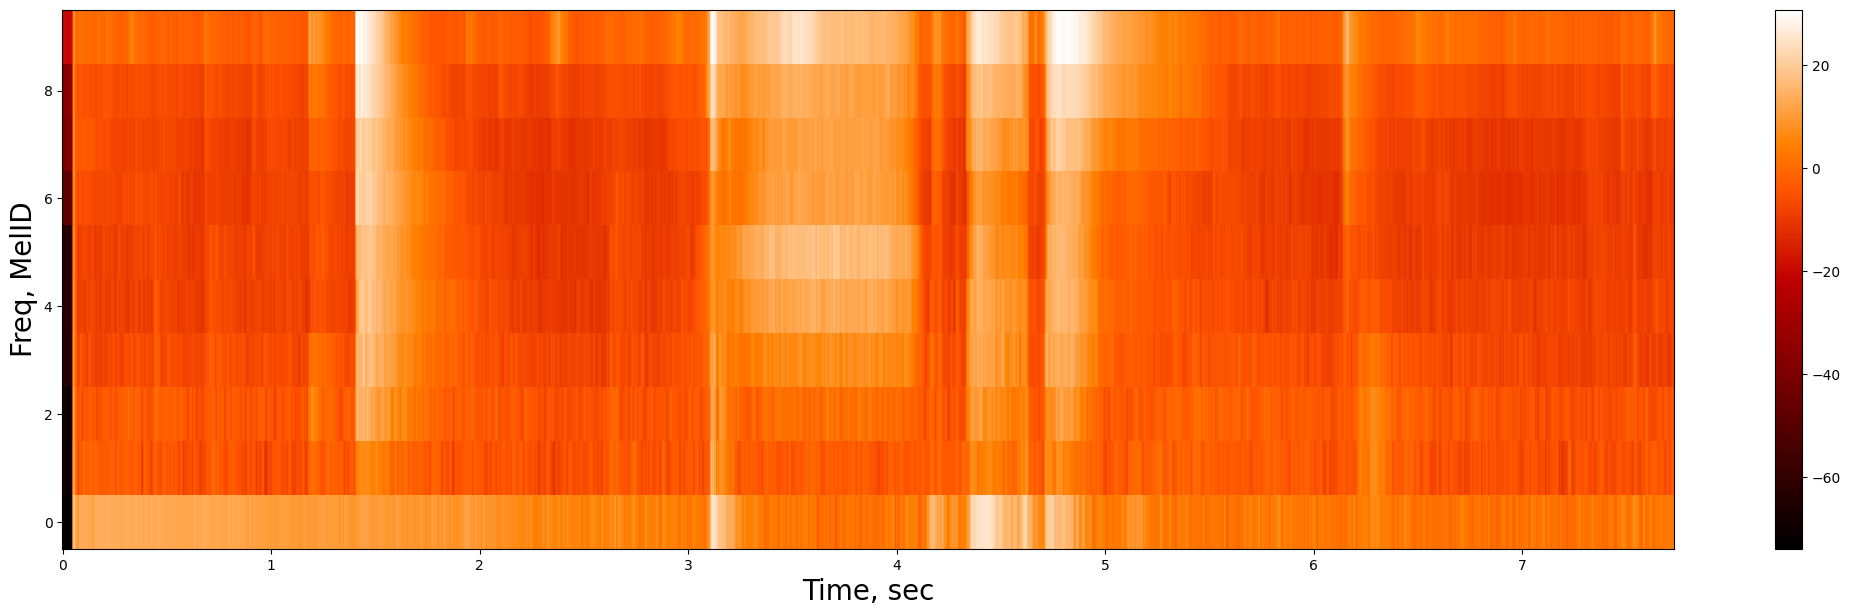

In [34]:
f,ax = plt.subplots(figsize=(26,7))

tGrid = np.arange(0, melSpectogram.shape[2]* hop_size, hop_size)/sr
fGrid = np.arange(nMels)
tt, ff = np.meshgrid(tGrid, fGrid)

im = ax.pcolormesh(tt, ff,melSpectogram.squeeze(), cmap="gist_heat")
ax.set_xlabel("Time, sec", size = 20)
ax.set_ylabel("Freq, MelID", size = 20)
f.colorbar(im)
plt.show()

## Built-In Spectogramms in PyTorch

In general, we can use pre-built Spectogramms that are combining windowing, stft, spectogramm and mel calc. This simplifies usage of spectogramms in pipelines.

In [44]:
melSpectogram = torchaudio.transforms.MelSpectrogram(
    sample_rate = sr,
    n_fft = nFFT,
    win_length = windowSize,
    hop_length = hop_size,
    n_mels = nMels,
    window_fn = torch.hann_window,
    center = False,
)

In [ ]:
Common Spectogramms are also availiable

In [42]:
specTransform = torchaudio.transforms.Spectrogram(
    n_fft = nFFT,
    win_length = windowSize,
    hop_length = hop_size,
    window_fn = torch.hann_window,
    center = False,
    )

## Impulse Response

Very powerfull modeing idea used in many audio effects. Theory is following:
  - There is clean signal x(t) ( can be analog, discrete, digital )
  - It is processed by the enviroment ( acoustics, instrumental stack, FX stack...)
  - Processed signal is y(t) is given as output

For example, acoustic FX like reverbiration can be modeled as following:
                y(t) = (x * h)(t),
convol kernel h(t) is called system's Impulse Response (IR) function

In [49]:
irWav, irSr = torchaudio.load("220752__jmuehlhans__impulse-response-church.wav")
resampleTransform = torchaudio.transforms.Resample(irSr, sr)
spec = specTransform(irWav)
freqsR = np.arange(0, nFFT/2 + 0.0001)/nFFT*sr


<ipython-input-17-fd3da920043c>:2: RuntimeWarning: invalid value encountered in log10
  return 2595 * np.log10(1 + f/700) # just a formual from wiki, we can use others too


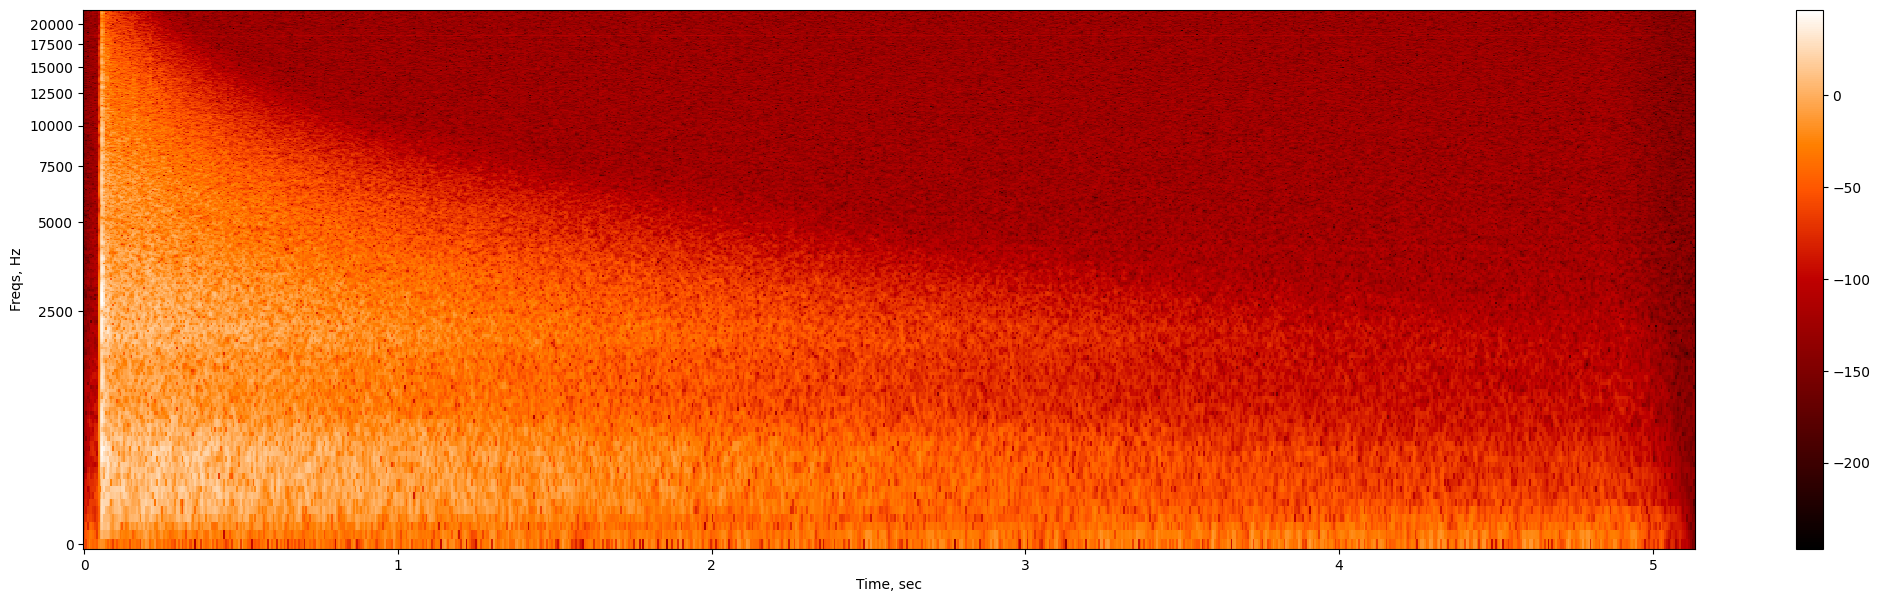

In [57]:
f, ax = plt.subplots(figsize=(26, 7 ))

tGrid = np.arange(0, spec.shape[2]* hop_size, hop_size)/sr
fGrid = freqsR
tt, ff = np.meshgrid(tGrid, fGrid)


im = ax.pcolormesh(tt, ff, 20 * torch.log10(spec.squeeze()), cmap="gist_heat")
ax.set_xlabel("Time, sec")
ax.set_ylabel("Freqs, Hz")
ax.set_yscale("function", functions =(mel_forward, mel_inverse))
f.colorbar(im)
plt.show()

In [63]:
display.display(display.Audio(irWav, rate = sr))

In [65]:
convTransform = torchaudio.transforms.FFTConvolve() # here we can choose modes - full,valid, same that will change output size and smth else
wavProcessed = convTransform(wav, irWav)
wavProcessedSpec = specTransform(wavProcessed)

<ipython-input-17-fd3da920043c>:2: RuntimeWarning: invalid value encountered in log10
  return 2595 * np.log10(1 + f/700) # just a formual from wiki, we can use others too


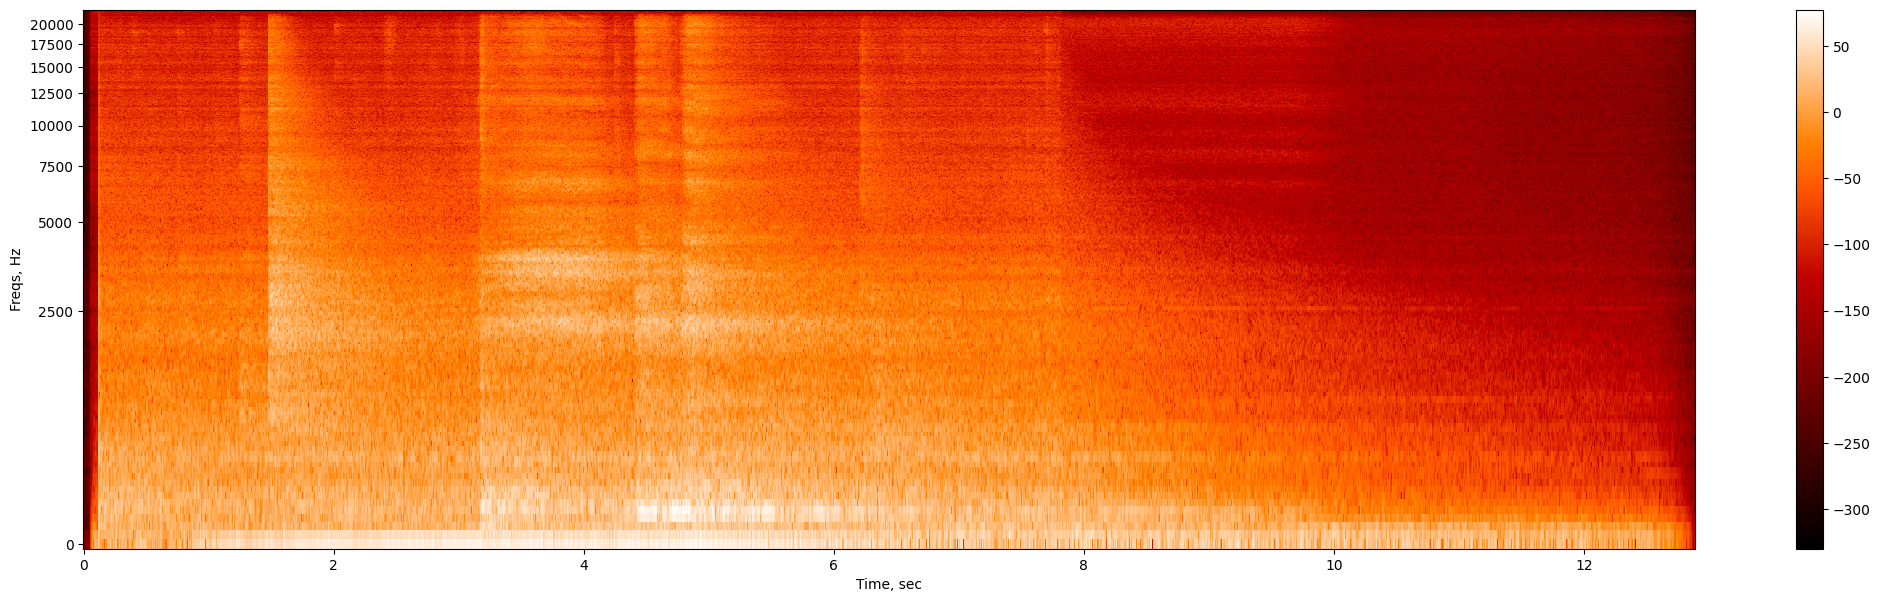

In [67]:
f, ax = plt.subplots(figsize = (26,7))

tGrid = np.arange(0, wavProcessedSpec.shape[2]* hop_size, hop_size)/sr
fGrid = freqsR
tt, ff = np.meshgrid(tGrid, fGrid)

im = ax.pcolormesh(tt,ff, 20 * torch.log10(wavProcessedSpec.squeeze()), cmap = "gist_heat")
ax.set_xlabel("Time, sec")
ax.set_ylabel("Freqs, Hz")
ax.set_yscale("function", functions = (mel_forward, mel_inverse))
f.colorbar(im)
plt.show()

In [69]:
display.display(display.Audio(wavProcessed, rate = sr))